In this notebook, we compare our previous best loss function (Proxy Anchor Loss) with a combined loss from Proxy Anchor Loss and Center loss.

## 1. Setup and Configuration

In [ ]:
EXPERIMENT_NAME = "balancing"
RANDOM_SEED = 2 # 2, 35, 78, 56, 432

import os

os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

from pathlib import Path
import sys

PROJECT_PATH = Path.cwd().parent
sys.path.insert(0, str(PROJECT_PATH))

from dotenv import load_dotenv

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
from tabulate import tabulate
import wandb
import pandas as pd
import matplotlib.pyplot as plt
import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_distances, cosine_similarity
from sklearn.preprocessing import LabelEncoder

from src.utils import (
    get_device,
    get_embeddings, extract_embeddings,
    set_seeds,
    create_deterministic_training_dataloader,
)
from src.criterions import CombinedLoss, CenterLoss, ProxyAnchorLoss
from src.models import EmbeddingProjection
from src.datasets import BlurImageDataset, EmbeddingDataset
from src.training import train_loop
from src.visualization import visualize_embeddings_mds, plot_history

set_seeds(RANDOM_SEED)

print(f"PyTorch version: {torch.__version__}")

All random seeds set to 2 for reproducibility
PyTorch version: 2.9.1+cu128


In [2]:
# Define paths
DATA_PATH = PROJECT_PATH / "data"
OUTPUT_PATH = PROJECT_PATH / "output" / EXPERIMENT_NAME
OUTPUT_PATH_SHARED = PROJECT_PATH / "output" / "shared"
CHECKPOINT_PATH = PROJECT_PATH / "checkpoints" / EXPERIMENT_NAME
EMBEDDINGS_PATH = CHECKPOINT_PATH / "embeddings"

DATA_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH_SHARED.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

# Load environment variables from .env file
load_dotenv(dotenv_path=PROJECT_PATH / ".env")

True

In [3]:
# Configuration
config = {       
    # Dinov3 Model
    "dinov3_model": "hf-hub:timm/vit_base_patch16_dinov3.lvd1689m",
    "dinov3_input_size": 224,

    # Model
    "embedding_dim": 256,
    "hidden_dim": 512,
    "dropout": 0.3,
    
    # ProxyAnchor
    "proxyanchor_margin": 0.1,
    "proxyanchor_alpha": 32.0,
    "proxyanchor_lambda": 0.0005,
    
    # Optimizer
    "init_learning_rate": 5e-3,
    "eta_min": 1e-5,
    "weight_decay": 1e-4,

    # Training
    "batch_size": 32,
    "weight_decay": 1e-4,
    "num_epochs": 200,
    "patience": 10,
    "val_split": 0.2,
    
    # Reproducibility
    "seed": RANDOM_SEED,
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  dinov3_model: hf-hub:timm/vit_base_patch16_dinov3.lvd1689m
  dinov3_input_size: 224
  embedding_dim: 256
  hidden_dim: 512
  dropout: 0.3
  proxyanchor_margin: 0.1
  proxyanchor_alpha: 32.0
  proxyanchor_lambda: 0.0005
  init_learning_rate: 0.005
  eta_min: 1e-05
  weight_decay: 0.0001
  batch_size: 32
  num_epochs: 200
  patience: 10
  val_split: 0.2
  seed: 2


In [4]:
# Initialize Weights and Biases for experiment tracking
# Key hyperparameters are tracked explicitly for easy filtering in W&B dashboard
if not os.getenv("WANDB_API_KEY"):
    print("Warning: WANDB_API_KEY not found in environment variables. W&B logging will be disabled.")
else:
    wandb.login()

    wandb.init(
        project="jaguar-reidentification",
        config=config,
        name=EXPERIMENT_NAME,
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: karl-schuetz (karl-schuetz-hasso-plattner-institut) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Data Loading

In [5]:
# Load training data
train_df = pd.read_csv(DATA_PATH / "train.csv").set_index("filename")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
               ground_truth
filename                   
train_0001.png        Abril
train_0002.png        Abril
train_0003.png        Abril
train_0004.png       Akaloi
train_0005.png       Akaloi


Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


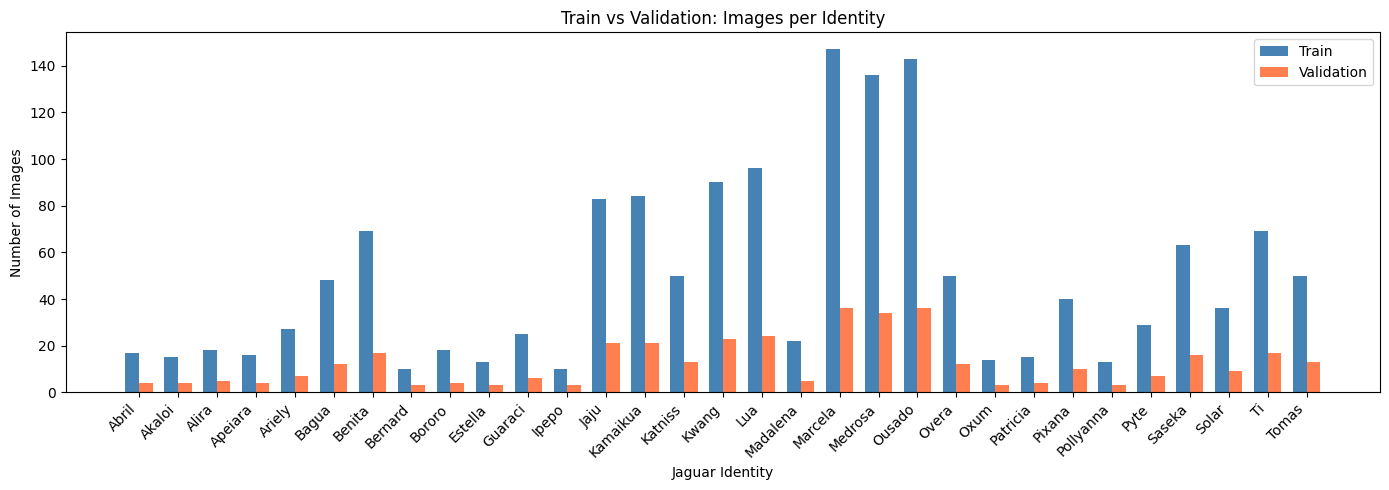


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [6]:
# Create stratified train/validation split
# This ensures all identities appear in both sets

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution": wandb.Image(fig)})
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

## Training Utils

In [7]:
device = get_device()
print(f"Using device: {device}")

Using CUDA GPU
Using device: cuda


In [8]:
num_workers = min(8, os.cpu_count())
print(f"Using num_workers={num_workers} for DataLoader")

Using num_workers=8 for DataLoader


In [9]:
filenames = train_df.index.astype(str)
train_mask = filenames.isin(train_data.index.astype(str))

filenames = filenames.to_numpy()
labels = train_df["label_encoded"].to_numpy()
image_paths = [DATA_PATH / "train" / fn for fn in filenames]

In [10]:
train_labels = train_data.loc[filenames[train_mask], "label_encoded"].values
val_labels = val_data.loc[filenames[~train_mask], "label_encoded"].values

In [11]:
# Load Dino model
print("Loading Dino model...")
dino = timm.create_model(
    config["dinov3_model"],
    pretrained=True
)
dino.eval()
dino.to(device)
dino.compile()

dino_config = resolve_data_config({}, model=dino)
dino_preprocess = create_transform(**dino_config, is_training=False)

dino_num_params = sum(p.numel() for p in dino.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {dino_num_params:,}")
print(f"  Preprocessing: {dino_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = dino_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = dino(dummy_input)
    dino_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {dino_dim}")

Loading Dino model...
Model loaded successfully
  Parameters: 85,641,216
  Preprocessing: {'input_size': [3, 256, 256], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 1.0, 'crop_mode': 'center'}
  Embedding dimension: 768


In [12]:
image_dataset = BlurImageDataset(image_paths, dino_preprocess)
image_loader = DataLoader(
    image_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False,
    pin_memory=True,
)

print(f"Image DataLoader created with {len(image_loader)} batches")

Image DataLoader created with 60 batches


In [13]:
baseline_cache_path = OUTPUT_PATH_SHARED / "dino_blur_embeddings.npz"

baseline_embeddings = get_embeddings(
    dino,
    baseline_cache_path,
    image_loader,
    filenames,
    device
)

Loaded cached embeddings from /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/shared/dino_blur_embeddings.npz
Embeddings shape: (1895, 768)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


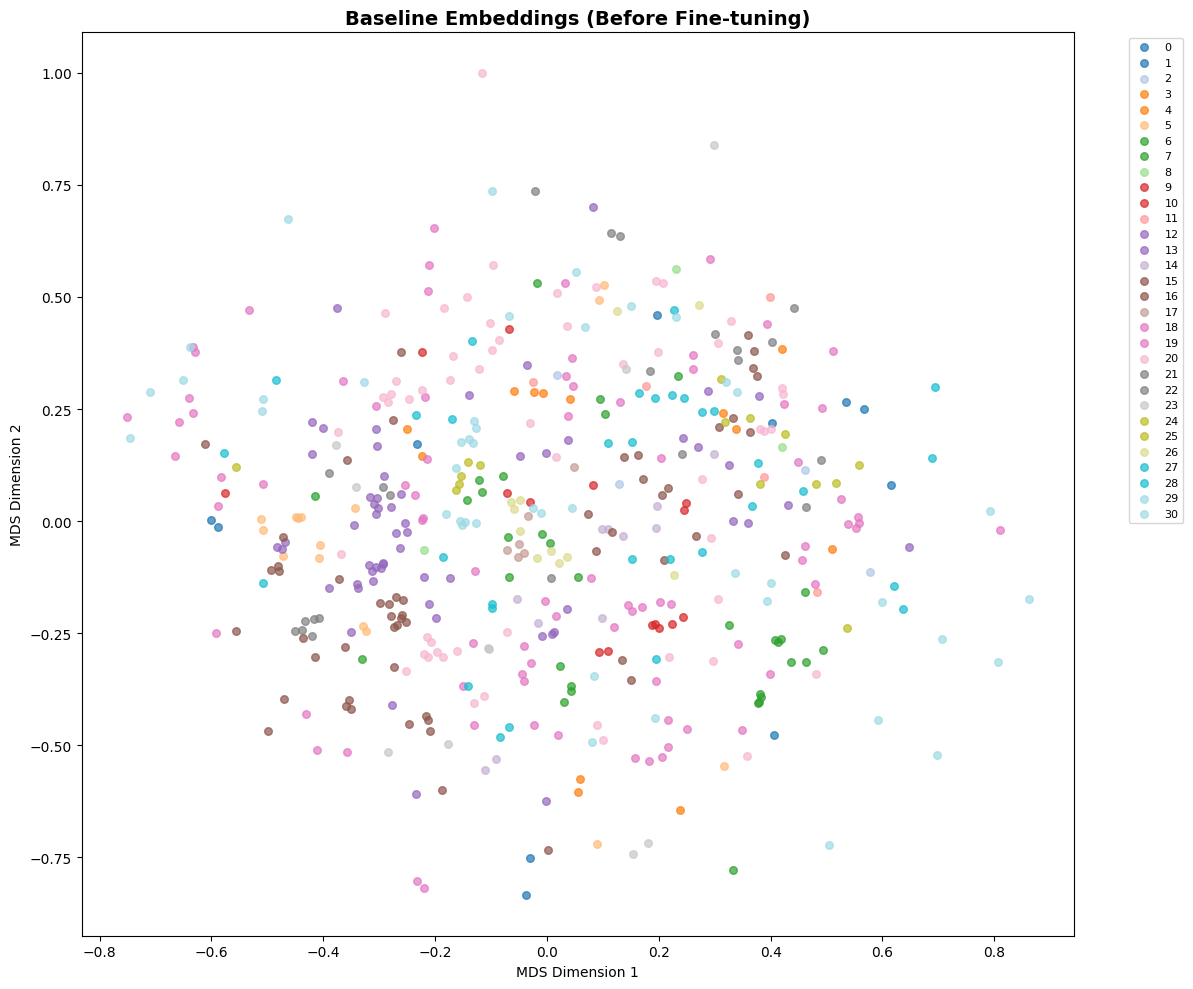

In [14]:
# Visualize DINO embeddings
fig = visualize_embeddings_mds(
    baseline_embeddings,
    labels,
    "Baseline Embeddings (Before Fine-tuning)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "baseline_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"baseline_embeddings_mds": wandb.Image(fig)})

In [ ]:
baseline_emb_train_dataset = EmbeddingDataset(
    baseline_embeddings[train_mask],
    train_labels
)

baseline_emb_val_dataset = EmbeddingDataset(
    baseline_embeddings[~train_mask],
    val_labels
)

baseline_emb_val_loader = DataLoader(
    baseline_emb_val_dataset,
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

In [16]:
# Create model
model = EmbeddingProjection(
    input_dim=dino_dim,
    hidden_dim=config["hidden_dim"],
    output_dim=config["embedding_dim"],
    dropout=config["dropout"],
).to(device)

model.print_model_summary()

Embedding Projection:
  Input dim: 768
  Hidden dim: 512
  Output dim: 256
  Dropout: 0.3
  Total parameters: 526592


In [ ]:
# Export initial model weights for reinitialization
initial_weights_path = CHECKPOINT_PATH / "model_initial_weights.pth"
torch.save(model.state_dict(), initial_weights_path)
print(f"Initial model weights saved to {initial_weights_path}")

In [17]:
criterion = CombinedLoss(
    first_loss=ProxyAnchorLoss(
        num_classes=num_classes, 
        embedding_dim=config["embedding_dim"], 
        margin=config["proxyanchor_margin"], 
        alpha=config["proxyanchor_alpha"]
    ),
    second_loss=CenterLoss(
        num_classes=num_classes, 
        embedding_dim=config["embedding_dim"]
    ),
    lambda_center=config["proxyanchor_lambda"]
).to(device)

In [ ]:
table = [
    ["Strategy", "val_mAP", "num_epochs"]
]

## Baseline

In [ ]:
baseline_emb_train_loader = create_deterministic_training_dataloader(
    baseline_emb_train_dataset,
    batch_size=config["batch_size"],
    seed=config['seed'],
    num_workers=num_workers,
    
)

In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path, map_location=device))

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["init_learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config["num_epochs"],
    eta_min=config["eta_min"]
)

print("Training components initialized:")
print(f"  Loss: ProxyAnchorLoss + CenterLoss")
print(f"  Optimizer: AdamW (lr={config['init_learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: CosineAnnealingLR (T_max={config['num_epochs']}, eta_min={config['eta_min']})")

Training components initialized:
  Loss: ProxyAnchorLoss + CenterLoss
  Optimizer: Adam (lr=0.005, weight_decay=0.0001)
  Scheduler: CosineAnnealingLR (T_max=200, eta_min=1e-05)


In [ ]:
# Training loop
set_seeds(config['seed'])
checkpoint_path = CHECKPOINT_PATH / "best_model_baseline.pth"
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="baseline",
    checkpoint_path=checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)

wandb.log({
    "final_val_mAP_baseline": best_map,
    "best_epoch_baseline": best_epoch,
    "total_epochs_baseline": len(history['train_loss']),
})

table.append(["Baseline", f"{best_map:.4f}", f"{len(history['train_loss'])}"])

All random seeds set to 2 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 8.2426
  Val Loss:   5.8816
  Val mAP:    0.2837 | LR: 5.00e-03
  [New best model saved]

Epoch 2/200


  Train Loss: 5.0865
  Val Loss:   2.1420
  Val mAP:    0.3914 | LR: 5.00e-03
  [New best model saved]

Epoch 3/200


  Train Loss: 2.5588
  Val Loss:   1.4368
  Val mAP:    0.5809 | LR: 5.00e-03
  [New best model saved]

Epoch 4/200


  Train Loss: 1.7547
  Val Loss:   1.2227
  Val mAP:    0.7078 | LR: 5.00e-03
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.1140
  Val Loss:   0.6736
  Val mAP:    0.8427 | LR: 4.32e-03
  No improvement. Patience: 6/10

Epoch 49/200


  Train Loss: 0.1005
  Val Loss:   0.6771
  Val mAP:    0.8446 | LR: 4.30e-03
  No improvement. Patience: 7/10

Epoch 50/200


  Train Loss: 0.1241
  Val Loss:   0.6866
  Val mAP:    0.8419 | LR: 4.27e-03
  No improvement. Patience: 8/10

Epoch 51/200


  Train Loss: 0.1542
  Val Loss:   0.7406
  Val mAP:    0.8419 | LR: 4.24e-03
  No improvement. Patience: 9/10

Epoch 52/200


  Train Loss: 0.1380
  Val Loss:   0.6844
  Val mAP:    0.8413 | LR: 4.21e-03
  No improvement. Patience: 10/10

Early stopping triggered after 52 epochs

Training complete!
Best epoch: 42, Val mAP: 0.8521


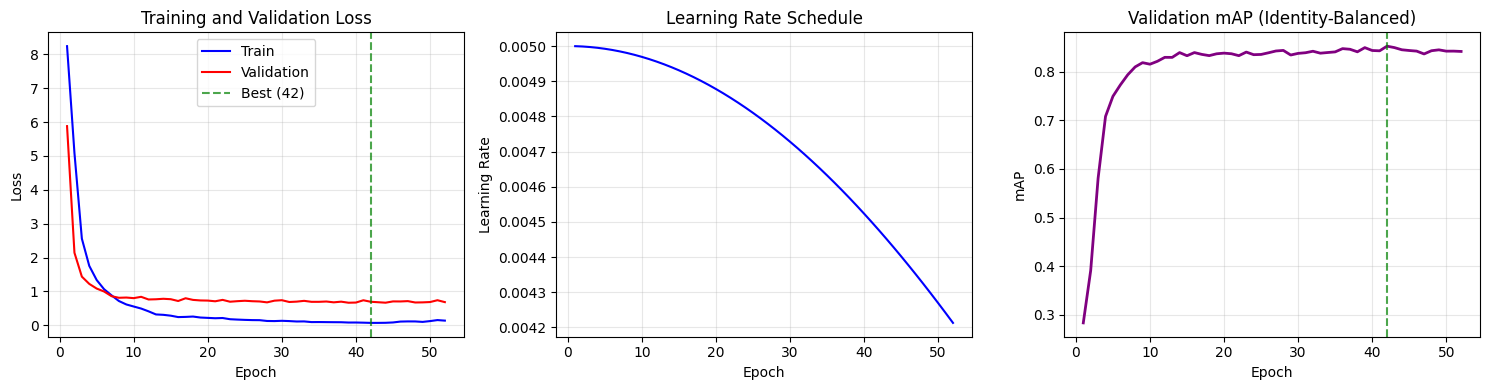

In [ ]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_baseline": wandb.Image(fig)})

In [22]:
# Load best model
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 42
  Val Loss: 0.6947
  Val mAP: 0.8521


In [23]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


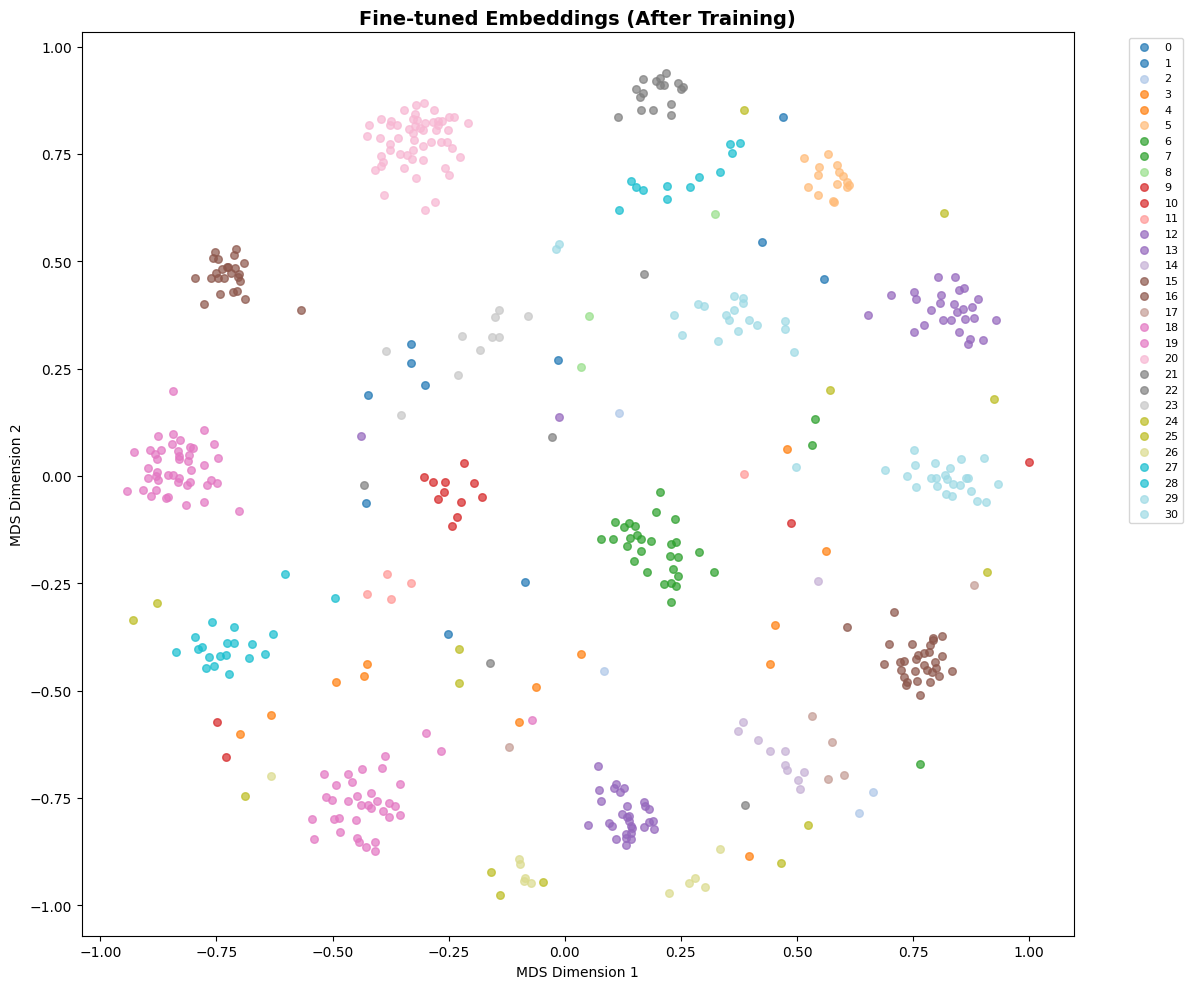

In [ ]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Fine-tuned Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "embeddings_mds_baseline.png")
plt.show()

# Log to W&B
wandb.log({"embeddings_mds_baseline": wandb.Image(fig_finetuned)})

In [25]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Weighted Sampling

In [ ]:
label_counts = train_data['ground_truth'].value_counts()
print(f"Label counts:\n{label_counts}")
class_weights = 1.0 / label_counts
# class_weights = class_weights / class_weights.sum()
class_weights

In [ ]:
# Assign a weight to each sample
sample_weights = [class_weights[label] for label in train_labels]
sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

baseline_emb_train_loader = create_deterministic_training_dataloader(
    baseline_emb_train_dataset,
    batch_size=config["batch_size"],
    seed=config['seed'],
    num_workers=num_workers,
    sampler=sampler
)

In [ ]:
# Setup training components
model.load_state_dict(torch.load(initial_weights_path, map_location=device))

optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(criterion.parameters()),
    lr=config["init_learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config["num_epochs"],
    eta_min=config["eta_min"]
)

print("Training components initialized:")
print(f"  Loss: ProxyAnchorLoss + CenterLoss")
print(f"  Optimizer: AdamW (lr={config['init_learning_rate']}, weight_decay={config['weight_decay']})")
print(f"  Scheduler: CosineAnnealingLR (T_max={config['num_epochs']}, eta_min={config['eta_min']})")

Training components initialized:
  Loss: ProxyAnchorLoss + CenterLoss
  Optimizer: Adam (lr=0.005, weight_decay=0.0001)
  Scheduler: CosineAnnealingLR (T_max=200, eta_min=1e-05)


In [ ]:
# Training loop
set_seeds(config['seed'])
checkpoint_path = CHECKPOINT_PATH / "best_model_weighted.pth"
history, best_map, best_epoch = train_loop(
    model, 
    baseline_emb_train_loader, 
    baseline_emb_val_loader, 
    criterion, 
    optimizer, 
    scheduler, 
    device,
    name="weighted",
    checkpoint_path=checkpoint_path,
    num_epochs=config["num_epochs"],
    patience=config["patience"],
    classes=label_encoder.classes_.tolist()
)

wandb.log({
    "final_val_mAP_weighted": best_map,
    "best_epoch_weighted": best_epoch,
    "total_epochs_weighted": len(history['train_loss']),
})

table.append(["Weighted", f"{best_map:.4f}", f"{len(history['train_loss'])}"])

All random seeds set to 2 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 8.2426
  Val Loss:   5.8816
  Val mAP:    0.2837 | LR: 5.00e-03
  [New best model saved]

Epoch 2/200


  Train Loss: 5.0865
  Val Loss:   2.1420
  Val mAP:    0.3914 | LR: 5.00e-03
  [New best model saved]

Epoch 3/200


  Train Loss: 2.5588
  Val Loss:   1.4368
  Val mAP:    0.5809 | LR: 5.00e-03
  [New best model saved]

Epoch 4/200


  Train Loss: 1.7547
  Val Loss:   1.2227
  Val mAP:    0.7078 | LR: 5.00e-03
  [New best model saved]

Epoch 5/200


...

  Train Loss: 0.1140
  Val Loss:   0.6736
  Val mAP:    0.8427 | LR: 4.32e-03
  No improvement. Patience: 6/10

Epoch 49/200


  Train Loss: 0.1005
  Val Loss:   0.6771
  Val mAP:    0.8446 | LR: 4.30e-03
  No improvement. Patience: 7/10

Epoch 50/200


  Train Loss: 0.1241
  Val Loss:   0.6866
  Val mAP:    0.8419 | LR: 4.27e-03
  No improvement. Patience: 8/10

Epoch 51/200


  Train Loss: 0.1542
  Val Loss:   0.7406
  Val mAP:    0.8419 | LR: 4.24e-03
  No improvement. Patience: 9/10

Epoch 52/200


  Train Loss: 0.1380
  Val Loss:   0.6844
  Val mAP:    0.8413 | LR: 4.21e-03
  No improvement. Patience: 10/10

Early stopping triggered after 52 epochs

Training complete!
Best epoch: 42, Val mAP: 0.8521


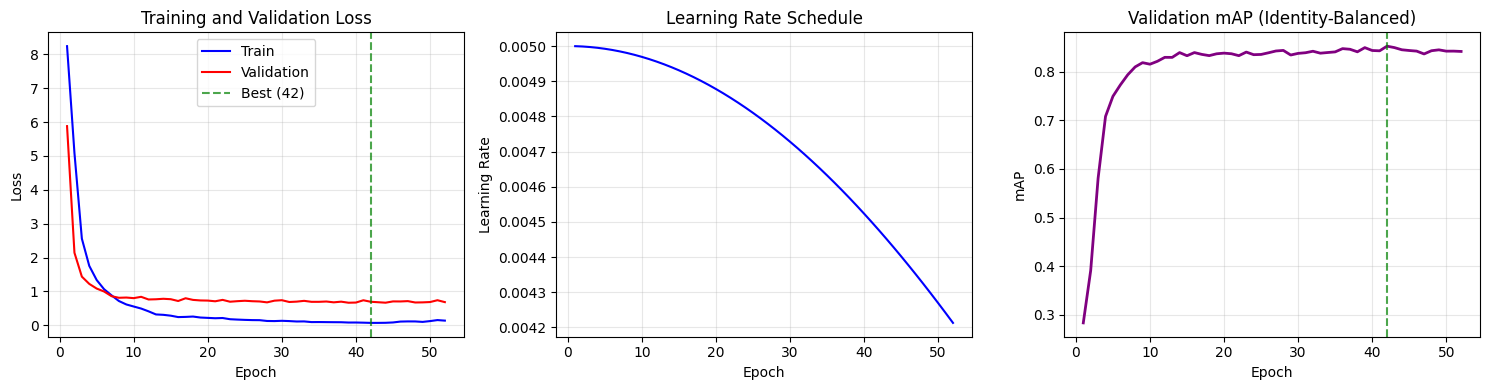

In [ ]:
# Plot training curves
fig = plot_history(history, best_epoch)
plt.savefig(CHECKPOINT_PATH / 'training_curves_weighted.png', dpi=150, bbox_inches='tight')
plt.show()

# Log to W&B
wandb.log({"training_curves_weighted": wandb.Image(fig)})

In [ ]:
# Load best model
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 42
  Val Loss: 0.6947
  Val mAP: 0.8521


In [ ]:
# Extract fine-tuned embeddings for training data
model.eval()
with torch.no_grad():
    train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
    finetuned_embeddings = model(train_tensor).cpu().numpy()
    finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")

Fine-tuned embeddings shape: (1895, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


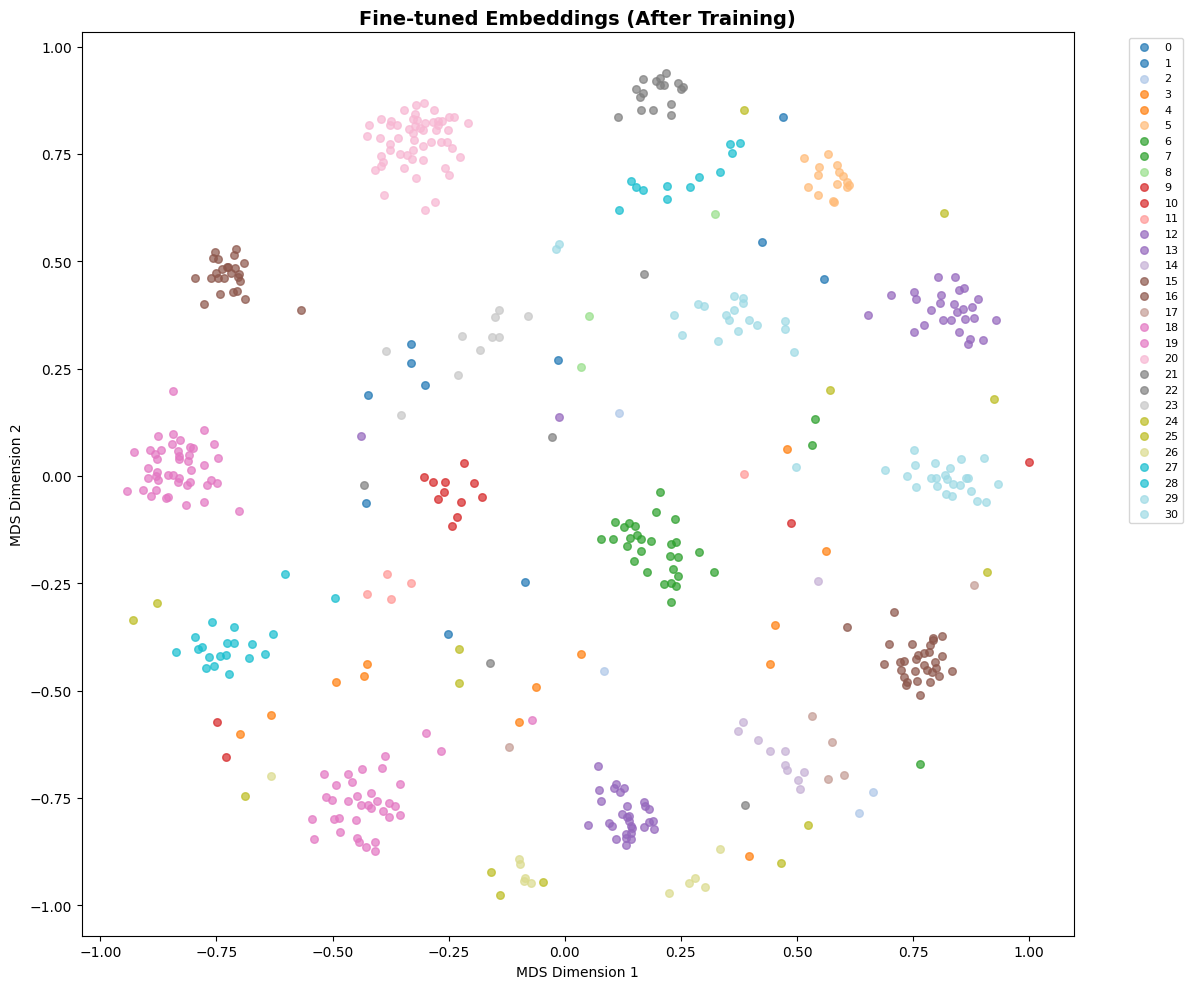

In [ ]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    finetuned_embeddings,
    labels,
    "Weighted Embeddings (After Training)",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "embeddings_mds_weighted.png")
plt.show()

# Log to W&B
wandb.log({"embeddings_mds_weighted": wandb.Image(fig_finetuned)})

In [ ]:
del optimizer, scheduler, history
torch.cuda.empty_cache()

## Summary

In [ ]:
rows = list(zip(*table)) # transpose for tabulate
print(tabulate(rows[1:], headers=rows[0], tablefmt="grid"))

## Submission

In [32]:
checkpoint = torch.load(CHECKPOINT_PATH / "best_model.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

EmbeddingProjection(
  (network): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

In [33]:
# Load test.csv to get the pairs we need to score
test_pairs_df = pd.read_csv(DATA_PATH / "test.csv")

print(f"Test pairs to score: {len(test_pairs_df)}")
print(f"Columns: {list(test_pairs_df.columns)}")
print(f"\nSample rows:")
print(test_pairs_df.head())

Test pairs to score: 137270
Columns: ['row_id', 'query_image', 'gallery_image']

Sample rows:
   row_id    query_image  gallery_image
0       0  test_0001.png  test_0002.png
1       1  test_0001.png  test_0003.png
2       2  test_0001.png  test_0004.png
3       3  test_0001.png  test_0005.png
4       4  test_0001.png  test_0006.png


In [34]:
# Get unique test images
test_images = set(test_pairs_df['query_image'].unique()) | set(test_pairs_df['gallery_image'].unique())
test_images = sorted(list(test_images))

print(f"Unique test images: {len(test_images)}")

# Build paths
test_image_paths = [DATA_PATH / "test" / filename for filename in test_images]

test_loader = DataLoader(
    BlurImageDataset(test_image_paths, dino_preprocess),
    batch_size=config["batch_size"],
    num_workers=num_workers,
    shuffle=False
)

# Extract embeddings for test images
print(f"\nExtracting embeddings for test images...")
test_embeddings = extract_embeddings(
    dino,
    test_loader,
    device,
    desc="Test embeddings"
)

print(f"Test embeddings shape: {test_embeddings.shape}")

Unique test images: 371

Extracting embeddings for test images...


Test embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Test embeddings: 100%|██████████| 12/12 [00:59<00:00,  4.96s/it]

Test embeddings shape: (371, 768)


In [35]:
# Project through fine-tuned model
model.eval()
with torch.no_grad():
    test_tensor = torch.FloatTensor(test_embeddings).to(device)
    test_finetuned_embeddings = model(test_tensor).cpu().numpy()
    test_finetuned_embeddings = test_finetuned_embeddings / np.linalg.norm(test_finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned test embeddings shape: {test_finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(test_finetuned_embeddings, axis=1).mean():.4f}")

# Create mapping from filename to embedding
img_to_embedding = {
    filename: embedding 
    for filename, embedding in zip(test_images, test_finetuned_embeddings)
}
img_to_index = {filename: idx for idx, filename in enumerate(test_images)}

Fine-tuned test embeddings shape: (371, 256)
Mean L2 norm: 1.0000


In [ ]:
# Visualize fine-tuned embeddings
fig_finetuned = visualize_embeddings_mds(
    test_finetuned_embeddings,
    ["test"] * len(test_images),  # No labels, just a single category
    "Test Embeddings",
    seed=config['seed']
)
plt.savefig(OUTPUT_PATH / "embeddings_mds_test.png")
plt.show()

# Log to W&B
wandb.log({"test_embeddings_mds": wandb.Image(fig_finetuned)})

In [ ]:
# Compute similarity for each pair
print("Computing pairwise similarities...")
similarities = []

# Compute cosine similarity matrix
sim_matrix = cosine_similarity(test_finetuned_embeddings)
np.fill_diagonal(sim_matrix, 1) # self-similarity

print(f"Similarity matrix shape: {sim_matrix.shape}", f"Sim range: [{sim_matrix.min():.4f}, {sim_matrix.max():.4f}]")

for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    query_id = img_to_index[row['query_image']]
    gallery_id = img_to_index[row['gallery_image']]
    similarity = sim_matrix[query_id, gallery_id]
    similarities.append(similarity)

# Clip to [0, 1] range
similarities = np.array(similarities)
similarities = np.clip(similarities, 0.0, 1.0)

print(f"\nSimilarity statistics:")
print(f"  Min: {similarities.min():.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Std: {similarities.std():.4f}")

Computing pairwise similarities...
Similarity matrix shape: (371, 371) Sim range: [0.0016, 1.0000]


Computing similarities: 100%|██████████| 137270/137270 [00:03<00:00, 38067.04it/s]


Similarity statistics:
  Min: 0.0016
  Max: 1.0000
  Mean: 0.8596
  Std: 0.1542


In [43]:
# Create submission DataFrame
submission_df = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

print("Submission DataFrame:")
print(submission_df.head(10))

# Verify format matches sample submission
sample_submission = pd.read_csv(DATA_PATH / "sample_submission.csv")
print(f"\nFormat check:")
print(f"  Expected columns: {list(sample_submission.columns)}")
print(f"  Our columns: {list(submission_df.columns)}")
print(f"  Expected rows: {len(sample_submission)}")
print(f"  Our rows: {len(submission_df)}")

Submission DataFrame:
   row_id  similarity
0       0    0.643482
1       1    0.882659
2       2    0.765042
3       3    0.810544
4       4    0.809093
5       5    0.638782
6       6    0.866316
7       7    0.840366
8       8    0.767672
9       9    0.810581

Format check:
  Expected columns: ['row_id', 'similarity']
  Our columns: ['row_id', 'similarity']
  Expected rows: 137270
  Our rows: 137270


In [44]:
# Save submission
submission_path = OUTPUT_PATH / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")

Submission saved to: /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/reranking/submission.csv
File size: 2217.3 KB
